In [1]:
import warnings

import numpy as np
import torch
from torch import nn

from neuralpredictors.layers import activations
from neuralpredictors.layers.encoders.base import Encoder

from nnfabrik.utility.nn_helpers import set_random_seed, get_dims_for_loader_dict
from neuralpredictors.utils import get_module_output
from neuralpredictors.layers.shifters import MLPShifter, StaticAffine2dShifter
from neuralpredictors.layers.cores import (
    Stacked2dCore,
    SE2dCore,
    RotationEquivariant2dCore,
)

from sensorium.models.readouts import MultipleFullGaussian2d
from sensorium.models.utility import prepare_grid

from perspective import Retina, Monitor, Perspective

from nnfabrik.builder import get_data, get_trainer

from functools import partial
from tqdm import tqdm

from neuralpredictors.measures import modules
from neuralpredictors.training import (
    early_stopping,
    MultipleObjectiveTracker,
    LongCycler,
)
from sensorium.utility import scores
from sensorium.utility.scores import get_correlations, get_poisson_loss

import matplotlib.pyplot as plt

random_seed = 42

device = "cuda:7"
torch.cuda.set_device(device)

In [2]:
class FiringRateEncoder(Encoder):
    def __init__(
        self,
        core,
        readout,
        *,
        perspective=None,
        shifter=None,
        modulator=None,
        elu_offset=0.0,
        nonlinearity_type="elu",
        nonlinearity_config=None
    ):
        """
        An Encoder that wraps the core, readout and optionally a shifter amd modulator into one model.
        The output is one positive value that can be interpreted as a firing rate, for example for a Poisson distribution.
        Args:
            core (nn.Module): Core model. Refer to neuralpredictors.layers.cores
            readout (nn.ModuleDict): MultiReadout model. Refer to neuralpredictors.layers.readouts
            elu_offset (float): Offset value in the final elu non-linearity. Defaults to 0.
            shifter (optional[nn.ModuleDict]): Shifter network. Refer to neuralpredictors.layers.shifters. Defaults to None.
            modulator (optional[nn.ModuleDict]): Modulator network. Modulator networks are not implemented atm (24/06/2021). Defaults to None.
            nonlinearity (str): Non-linearity type to use. Defaults to 'elu'.
            nonlinearity_config (optional[dict]): Non-linearity configuration. Defaults to None.
        """
        super().__init__()
        self.core = core
        self.readout = readout
        self.perspective=perspective
        self.shifter = shifter
        self.modulator = modulator
        self.offset = elu_offset

        if nonlinearity_type != "elu" and not np.isclose(elu_offset, 0.0):
            warnings.warn("If `nonlinearity_type` is not 'elu', `elu_offset` will be ignored")
        if nonlinearity_type == "elu":
            self.nonlinearity_fn = nn.ELU()
        elif nonlinearity_type == "identity":
            self.nonlinearity_fn = nn.Identity()
        else:
            self.nonlinearity_fn = activations.__dict__[nonlinearity_type](
                **nonlinearity_config if nonlinearity_config else {}
            )
        self.nonlinearity_type = nonlinearity_type

    def forward(
        self,
        inputs,
        *args,
        targets=None,
        data_key=None,
        behavior=None,
        pupil_center=None,
        trial_idx=None,
        shift=None,
        detach_core=False,
        **kwargs
    ):
        if self.perspective:
            # if shift is defined - no need to change it
            if pupil_center is None:
                raise ValueError("pupil_center is not given")
            x = self.perspective(inputs, pupil_center)
            self.shifter=None
        else:
            x = inputs

        x = self.core(x)
        if detach_core:
            x = x.detach()

        if self.shifter and shift is None:
            # if shift is defined - no need to change it
            if pupil_center is None:
                raise ValueError("pupil_center is not given")
            shift = self.shifter[data_key](pupil_center, trial_idx)

        x = self.readout(x, data_key=data_key, shift=shift, **kwargs)
        x = x[None, ...] if len(x.shape) == 1 else x  # keep dimensions if only one image was passed

        if self.modulator:
            if behavior is None:
                raise ValueError("behavior is not given")
            x = self.modulator[data_key](x, behavior=behavior)

        if self.nonlinearity_type == "elu":
            return self.nonlinearity_fn(x + self.offset) + 1
        else:
            return self.nonlinearity_fn(x)

    def predict_mean(self, x, *args, data_key=None, **kwargs):
        return self.forward(x, *args, data_key=data_key, **kwargs)

    def predict_variance(self, x, *args, data_key=None, **kwargs):
        return self.forward(x, *args, data_key=data_key, **kwargs)


In [3]:
def stacked_core_full_gauss_readout(
    dataloaders,
    seed,
    hidden_channels=32,
    input_kern=13,
    hidden_kern=3,
    layers=3,
    gamma_input=15.5,
    skip=0,
    final_nonlinearity=True,
    momentum=0.9,
    pad_input=False,
    batch_norm=True,
    hidden_dilation=1,
    laplace_padding=None,
    input_regularizer="LaplaceL2norm",
    use_avg_reg=False,
    init_mu_range=0.2,
    init_sigma=1.0,
    readout_bias=True,
    gamma_readout=4,
    elu_offset=0,
    stack=None,
    depth_separable=False,
    linear=False,
    gauss_type="full",
    grid_mean_predictor=None,
    attention_conv=False,
    perspective=None,
    shifter=None,
    shifter_type="MLP",
    input_channels_shifter=2,
    hidden_channels_shifter=5,
    shift_layers=3,
    gamma_shifter=0,
    shifter_bias=True,
    hidden_padding=None,
    core_bias=True,
):
    """
    Model class of a stacked2dCore (from neuralpredictors) and a pointpooled (spatial transformer) readout

    Args:
        dataloaders: a dictionary of dataloaders, one loader per session
            in the format {'data_key': dataloader object, .. }
        seed: random seed
        grid_mean_predictor: if not None, needs to be a dictionary of the form
            {
            'type': 'cortex',
            'input_dimensions': 2,
            'hidden_layers':0,
            'hidden_features':20,
            'final_tanh': False,
            }
            In that case the datasets need to have the property `neurons.cell_motor_coordinates`
        share_features: whether to share features between readouts. This requires that the datasets
            have the properties `neurons.multi_match_id` which are used for matching. Every dataset
            has to have all these ids and cannot have any more.
        all other args: See Documentation of Stacked2dCore in neuralpredictors.layers.cores and
            PointPooled2D in neuralpredictors.layers.readouts

    Returns: An initialized model which consists of model.core and model.readout
    """

    if "train" in dataloaders.keys():
        dataloaders = dataloaders["train"]

    # Obtain the named tuple fields from the first entry of the first dataloader in the dictionary
    batch = next(iter(list(dataloaders.values())[0]))
    in_name, out_name = (
        list(batch.keys())[:2] if isinstance(batch, dict) else batch._fields[:2]
    )

    session_shape_dict = get_dims_for_loader_dict(dataloaders)
    n_neurons_dict = {k: v[out_name][1] for k, v in session_shape_dict.items()}
    input_channels = [v[in_name][1] for v in session_shape_dict.values()]

    core_input_channels = (
        list(input_channels.values())[0]
        if isinstance(input_channels, dict)
        else input_channels[0]
    )

    set_random_seed(seed)
    grid_mean_predictor, grid_mean_predictor_type, source_grids = prepare_grid(grid_mean_predictor, dataloaders)

    core = Stacked2dCore(
        input_channels=core_input_channels,
        hidden_channels=hidden_channels,
        input_kern=input_kern,
        hidden_kern=hidden_kern,
        layers=layers,
        gamma_input=gamma_input,
        skip=skip,
        final_nonlinearity=final_nonlinearity,
        bias=core_bias,
        momentum=momentum,
        pad_input=pad_input,
        batch_norm=batch_norm,
        hidden_dilation=hidden_dilation,
        laplace_padding=laplace_padding,
        input_regularizer=input_regularizer,
        stack=stack,
        depth_separable=depth_separable,
        linear=linear,
        attention_conv=attention_conv,
        hidden_padding=hidden_padding,
        use_avg_reg=use_avg_reg,
    )

    in_shapes_dict = {
        k: get_module_output(core, v[in_name])[1:]
        for k, v in session_shape_dict.items()
    }

    readout = MultipleFullGaussian2d(
        in_shape_dict=in_shapes_dict,
        loader=dataloaders,
        n_neurons_dict=n_neurons_dict,
        init_mu_range=init_mu_range,
        bias=readout_bias,
        init_sigma=init_sigma,
        gamma_readout=gamma_readout,
        gauss_type=gauss_type,
        grid_mean_predictor=grid_mean_predictor,
        grid_mean_predictor_type=grid_mean_predictor_type,
        source_grids=source_grids,
    )

    if shifter is True:
        data_keys = [i for i in dataloaders.keys()]
        if shifter_type == "MLP":
            shifter = MLPShifter(
                data_keys=data_keys,
                input_channels=input_channels_shifter,
                hidden_channels_shifter=hidden_channels_shifter,
                shift_layers=shift_layers,
                gamma_shifter=gamma_shifter,
            )

        elif shifter_type == "StaticAffine":
            shifter = StaticAffine2dShifter(
                data_keys=data_keys,
                input_channels=input_channels_shifter,
                bias=shifter_bias,
                gamma_shifter=gamma_shifter,
            )

    model = FiringRateEncoder(
        core=core,
        readout=readout,
        perspective=perspective,
        shifter=shifter,
        elu_offset=elu_offset,
    )

    return model


In [4]:
# loading the SENSORIUM+ dataset
filenames = ['/srv/user/polina/sensorium/sensorium/notebooks/data/static27204-5-13-GrayImageNet-94c6ff995dac583098847cfecd43e7b6.zip', ]

dataset_fn = 'sensorium.datasets.static_loaders'
dataset_config = {'paths': filenames,
                 'normalize': True,
                 'include_behavior': False,
                 'include_eye_position': True,
                 'batch_size': 128,
                 'scale':0.25,
                 }

dataloaders = get_data(dataset_fn, dataset_config)

In [5]:
grid_mean_predictor = {
    'type': 'cortex',
    'input_dimensions': 2,
    'hidden_layers': 1,
    'hidden_features': 30,
    'final_tanh': True
}

model_config = {'pad_input': False,
  'stack': -1,
  'layers': 4,
  'input_kern': 9,
  'gamma_input': 6.3831,
  'gamma_readout': 0.0076,
  'hidden_kern': 7,
  'hidden_channels': 64,
  'depth_separable': True,
  'grid_mean_predictor': {'type': 'cortex',
   'input_dimensions': 2,
   'hidden_layers': 1,
   'hidden_features': 30,
   'final_tanh': True},
  'init_sigma': 0.1,
  'init_mu_range': 0.3,
  'gauss_type': 'full',
  'shifter': False,
}

perspective = Perspective(Retina(mlp_features=[8, 8], device=device), Monitor(device=device)).to(device)
model_config['perspective'] = perspective

In [6]:
model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


In [7]:
trainer_fn = "sensorium.training.standard_trainer"

trainer_config = {'max_iter': 200,
                 'verbose': True,
                 'lr_decay_steps': 4,
                 'avg_loss': False,
                 'lr_init': 0.009,
                 'track_training': True,
                 }

trainer_config['device'] = 'cuda:7'

trainer = get_trainer(trainer_fn=trainer_fn, 
                     trainer_config=trainer_config)

In [8]:
validation_score, trainer_output, state_dict = trainer(model, dataloaders, seed=42)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/gaussian.py:582: UserWarning: the specified feature map dimension is not the readout's expected input dimension
  warnings.warn("the specified feature map dimension is not the readout's expected input dimension")


correlation -0.0027238578
poisson_loss 4078652.5


Epoch 1: 100%|██████████| 35/35 [00:29<00:00,  1.20it/s]


correlation 0.052458033
poisson_loss 2711907.8


Epoch 2: 100%|██████████| 35/35 [00:26<00:00,  1.34it/s]


...

Epoch 108: 100%|██████████| 35/35 [00:26<00:00,  1.32it/s]


correlation 0.31919062
poisson_loss 2345685.0


Epoch 109: 100%|██████████| 35/35 [00:26<00:00,  1.32it/s]


correlation 0.31881282
poisson_loss 2344987.0


Epoch 110: 100%|██████████| 35/35 [00:26<00:00,  1.31it/s]


In [9]:
validation_score

np.float32(0.32435307)

In [15]:
list(perspective.parameters())

[Parameter containing:
 tensor([[-0.3682, -0.3769],
         [ 0.7348, -0.1708],
         [-0.3627, -0.2687],
         [ 0.2787, -0.0647],
         [ 0.5109,  0.2595],
         [-0.4658,  0.3065],
         [-0.4121,  0.3131],
         [ 0.0441,  0.4938]], device='cuda:7', requires_grad=True),
 Parameter containing:
 tensor([ 0.1885, -0.1363, -0.6464,  0.3475, -1.0635, -0.3136, -0.7677, -0.0493],
        device='cuda:7', requires_grad=True),
 Parameter containing:
 tensor([[-0.0680, -0.2841, -0.1633, -0.2474, -0.1737, -0.4543,  0.1065,  0.0642],
         [-0.6807, -0.2129,  0.1328,  0.1990,  0.2523,  0.0889, -0.7781,  0.1275],
         [-0.2336, -0.1568,  0.1755, -0.2337, -0.3064, -0.4001, -0.3330,  0.1041],
         [-0.2885,  0.2873, -0.3848, -0.1164,  0.1459,  0.0402, -0.2331,  0.3824],
         [-0.3221, -0.1803, -0.2639, -0.1150, -0.2702,  0.1692,  0.0041, -0.2782],
         [-0.3295, -0.0885, -0.1494, -0.3071, -0.0929,  0.0487, -0.2496, -0.3095],
         [-0.2914, -0.2606, -0.268

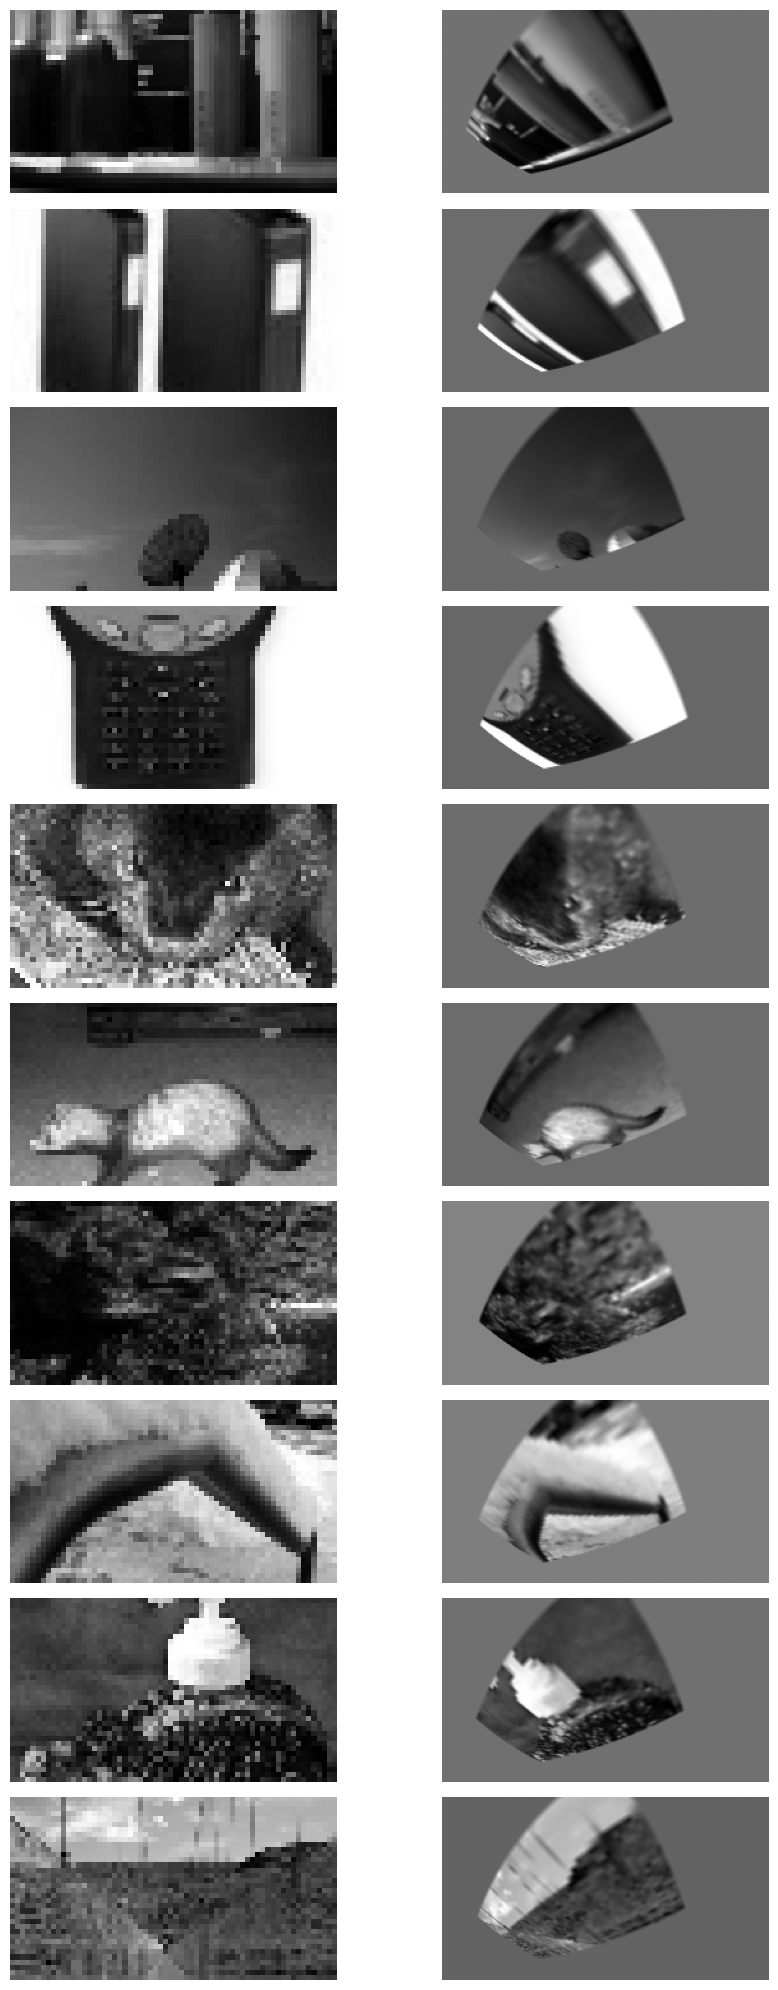

In [24]:
data_key = "27204-5-13"
batch = next(iter(dataloaders["train"][data_key]))

fig, ax = plt.subplots(10, 2, figsize=(10, 20))

for i in range(10):
    ax[i, 0].imshow(batch.images[i, 0].detach().cpu(), cmap='gray')
    ax[i, 0].axis('off')
    ax[i, 1].imshow(perspective(batch.images, batch.pupil_center)[i, 0].detach().cpu(), cmap='gray')
    ax[i, 1].axis('off')

plt.tight_layout()